<a href="https://colab.research.google.com/github/chavacodezen/Maestria-IA/blob/main/Actividad_%C3%81rbol_de_Decisi%C3%B3n_para_Regresi%C3%B3n_California_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 👤 **Estudiante**
- **Nombre:** Bryan Fernando Chavarria Martinez  
- **Matrícula:** 268838

### **Actividad: Árbol de Decisión para Regresión**

#### **📌 Objetivo:**  
Analizar el comportamiento de un modelo de árbol de decisión en un problema de regresión, evaluando su capacidad de generalización mediante el estudio del sobreajuste, la profundidad del árbol y la poda.

### **📌  Dataset:**  
Se utilizará el dataset California Housing, disponible en scikit-learn.


### **📋 Instrucciones**  

#### **🔹 1. Carga y exploración de datos**
✅ Cargar el dataset en un DataFrame

✅ Identificar la variable objetivo (MedHouseVal)  

✅ Analizar la estructura del dataset (info, describe)

✅ Visualizar la distribución de la variable objetivo

Variable objetivo : MedHouseVal
Features          : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

── shape ──
(20640, 9)

── info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

── valores nulos ──
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

── describe ──


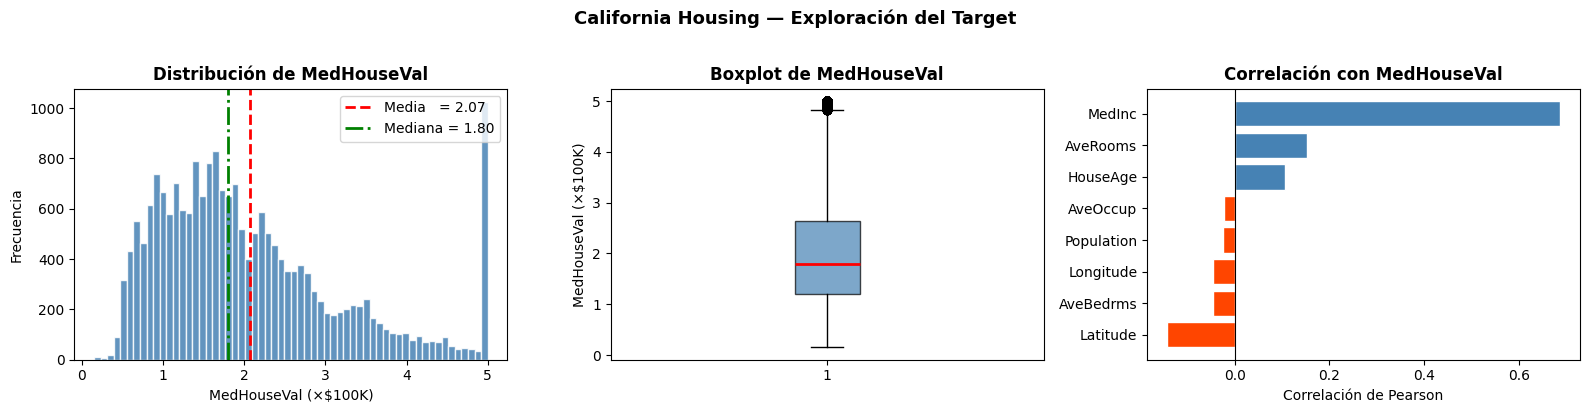

In [1]:
# ── Librerías ─────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# ── Cargar dataset en DataFrame ───────────────────────────────────────────────
datos = fetch_california_housing(as_frame=True)
df    = datos.frame

# ── Variable objetivo ─────────────────────────────────────────────────────────
TARGET   = 'MedHouseVal'
FEATURES = [c for c in df.columns if c != TARGET]
print(f"Variable objetivo : {TARGET}")
print(f"Features          : {FEATURES}")

# ── Estructura del dataset ────────────────────────────────────────────────────
print("\n── shape ──")
print(df.shape)

print("\n── info ──")
df.info()

print("\n── valores nulos ──")
print(df.isnull().sum())

print("\n── describe ──")
df.describe().round(3)

# ── Distribución de la variable objetivo ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma + líneas estadísticas
axes[0].hist(df[TARGET], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df[TARGET].mean(),   color='red',   linestyle='--', linewidth=2,
                label=f'Media   = {df[TARGET].mean():.2f}')
axes[0].axvline(df[TARGET].median(), color='green', linestyle='-.', linewidth=2,
                label=f'Mediana = {df[TARGET].median():.2f}')
axes[0].set_title('Distribución de MedHouseVal', fontweight='bold')
axes[0].set_xlabel('MedHouseVal (×$100K)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
axes[1].boxplot(df[TARGET], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot de MedHouseVal', fontweight='bold')
axes[1].set_ylabel('MedHouseVal (×$100K)')

# Correlaciones con el target
corr = df.corr()[TARGET].drop(TARGET).sort_values()
colors = ['orangered' if v < 0 else 'steelblue' for v in corr]
axes[2].barh(corr.index, corr.values, color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Correlación con MedHouseVal', fontweight='bold')
axes[2].set_xlabel('Correlación de Pearson')

plt.suptitle('California Housing — Exploración del Target', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### **🔹 2. Preparación de datos**  
📊 **Definir:**  
- X: variables predictoras  
- y: variable objetivo

📊 **Dividir los datos en entrenamiento (80%) y prueba (20%)**  

In [2]:
# ── Variables predictoras y objetivo ──────────────────────────────────────────
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# ── División entrenamiento / prueba ───────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nEntrenamiento : {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba        : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")

X shape: (20640, 8)
y shape: (20640,)

Entrenamiento : 16,512 muestras (80%)
Prueba        : 4,128 muestras (20%)


#### **🔹 3. Modelo base**  
✅ Entrenar un árbol de decisión sin restricciones (max_depth=None)

✅ Evaluar el modelo usando: RMSE y R²

✅ Comparar desempeño en entrenamiento y prueba

✅ Determinar si existe sobreajuste

In [3]:
# ── Entrenar árbol sin restricciones ──────────────────────────────────────────
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

arbol_base = DecisionTreeRegressor(max_depth=None, random_state=42)
arbol_base.fit(X_train, y_train)

# ── Predicciones ──────────────────────────────────────────────────────────────
y_pred_train = arbol_base.predict(X_train)
y_pred_test  = arbol_base.predict(X_test)

# ── Métricas ──────────────────────────────────────────────────────────────────
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print(f"{'Métrica':<10} {'Entrenamiento':>15} {'Prueba':>10}")
print("-" * 37)
print(f"{'RMSE':<10} {rmse_train:>15.4f} {rmse_test:>10.4f}")
print(f"{'R²':<10} {r2_train:>15.4f} {r2_test:>10.4f}")
print(f"\nProfundidad del árbol : {arbol_base.get_depth()}")
print(f"Número de hojas       : {arbol_base.get_n_leaves():,}")

# ── Diagnóstico de sobreajuste ────────────────────────────────────────────────
diferencia_r2 = r2_train - r2_test
print(f"\nDiferencia R² (train - test) : {diferencia_r2:.4f}")
if diferencia_r2 > 0.1:
    print("⚠️  Sobreajuste detectado — el modelo memoriza el entrenamiento")
else:
    print("✅ Sin sobreajuste significativo")

Métrica      Entrenamiento     Prueba
-------------------------------------
RMSE                0.0000     0.7037
R²                  1.0000     0.6221

Profundidad del árbol : 34
Número de hojas       : 15,854

Diferencia R² (train - test) : 0.3779
⚠️  Sobreajuste detectado — el modelo memoriza el entrenamiento


#### **🔹 4. Análisis Bias–Variance**  
✅ Entrenar múltiples modelos variando el parámetro max_depth de 1 a 21.

✅ Graficar el error (RMSE) en entrenamiento y prueba

✅ Identificar el punto donde el modelo generaliza mejor

Mejor profundidad : 9
Menor RMSE prueba : 0.6443


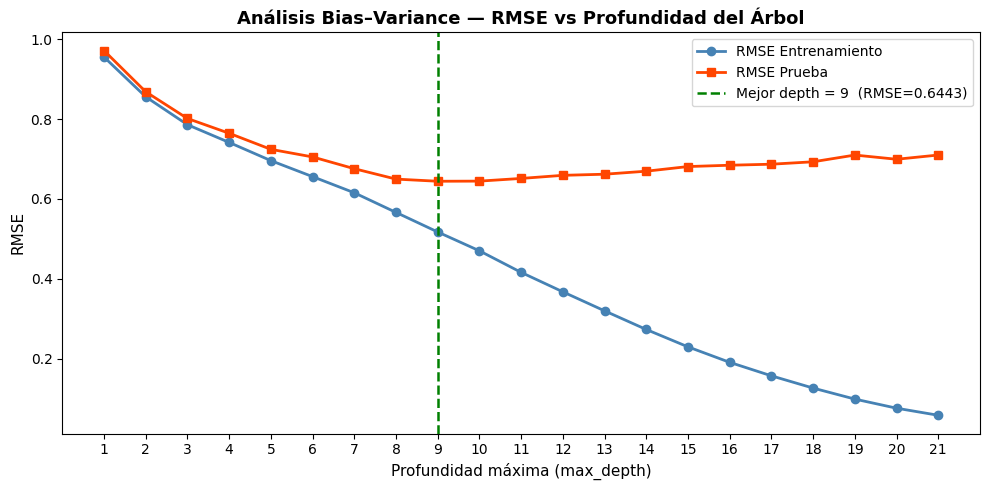


Depth      RMSE Train    RMSE Test
----------------------------------
1              0.9555       0.9717
2              0.8559       0.8685
3              0.7860       0.8015
4              0.7415       0.7645
5              0.6959       0.7242
6              0.6558       0.7052
7              0.6154       0.6757
8              0.5662       0.6497
9              0.5172       0.6443 ← óptimo
10             0.4700       0.6446
11             0.4159       0.6513
12             0.3672       0.6591
13             0.3196       0.6619
14             0.2729       0.6695
15             0.2293       0.6811
16             0.1906       0.6844
17             0.1568       0.6870
18             0.1261       0.6930
19             0.0985       0.7099
20             0.0757       0.6994
21             0.0579       0.7100


In [4]:
# ── RMSE por profundidad ───────────────────────────────────────────────────────
profundidades   = range(1, 22)
rmse_train_list = []
rmse_test_list  = []

for d in profundidades:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    rmse_train_list.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_test_list.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test))))

# ── Mejor profundidad ─────────────────────────────────────────────────────────
mejor_depth = profundidades[np.argmin(rmse_test_list)]
mejor_rmse  = min(rmse_test_list)
print(f"Mejor profundidad : {mejor_depth}")
print(f"Menor RMSE prueba : {mejor_rmse:.4f}")

# ── Gráfica Bias–Variance ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(profundidades, rmse_train_list, 'o-', color='steelblue', linewidth=2, label='RMSE Entrenamiento')
plt.plot(profundidades, rmse_test_list,  's-', color='orangered',  linewidth=2, label='RMSE Prueba')
plt.axvline(mejor_depth, color='green', linestyle='--', linewidth=1.8,
            label=f'Mejor depth = {mejor_depth}  (RMSE={mejor_rmse:.4f})')
plt.xlabel('Profundidad máxima (max_depth)', fontsize=11)
plt.ylabel('RMSE', fontsize=11)
plt.title('Análisis Bias–Variance — RMSE vs Profundidad del Árbol', fontsize=13, fontweight='bold')
plt.xticks(profundidades)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Interpretación ────────────────────────────────────────────────────────────
print(f"\n{'Depth':<8} {'RMSE Train':>12} {'RMSE Test':>12}")
print("-" * 34)
for d, tr, te in zip(profundidades, rmse_train_list, rmse_test_list):
    marca = " ← óptimo" if d == mejor_depth else ""
    print(f"{d:<8} {tr:>12.4f} {te:>12.4f}{marca}")

#### **🔹 5. Poda del árbol**  
✅ Aplicar cost-complexity pruning (ccp_alpha)

✅ Evaluar distintos valores de ccp_alpha con ccp_alphas = ccp_alphas[::5]

✅ Analizar su efecto en el error del modelo

Total de alphas evaluados : 60
Rango: 0.000000 → 0.000944

Mejor ccp_alpha : 0.000251
Menor RMSE Test : 0.6298


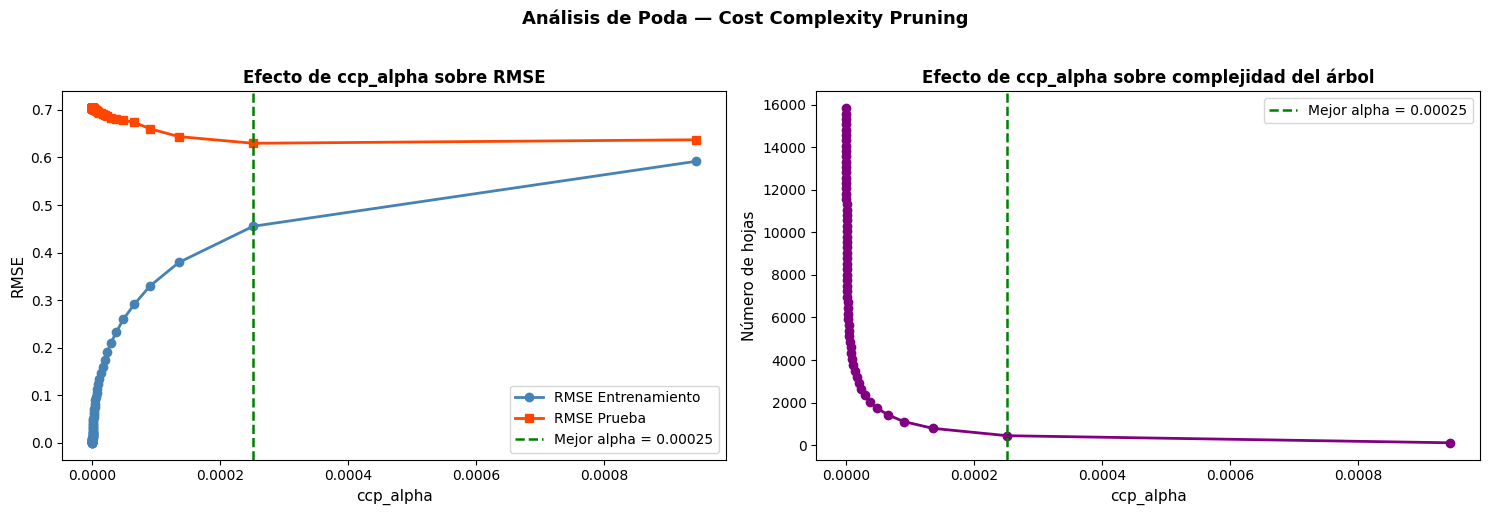


       Alpha   RMSE Train    RMSE Test    Hojas
------------------------------------------------
    0.000000       0.0000       0.7037    15854
    0.000000       0.0001       0.7037    15586
    0.000000       0.0003       0.7037    15337
    0.000000       0.0005       0.7037    15088
    0.000000       0.0008       0.7037    14838
    0.000000       0.0012       0.7037    14587
    0.000000       0.0016       0.7037    14336
    0.000000       0.0020       0.7037    14085
    0.000000       0.0025       0.7037    13836
    0.000000       0.0031       0.7037    13582
    0.000000       0.0036       0.7037    13334
    0.000000       0.0043       0.7038    13083
    0.000000       0.0050       0.7038    12827
    0.000000       0.0058       0.7039    12578
    0.000000       0.0066       0.7039    12331
    0.000000       0.0075       0.7038    12081
    0.000000       0.0085       0.7038    11829
    0.000000       0.0096       0.7038    11576
    0.000000       0.0107       0.7037

In [7]:
# ── Obtener alphas disponibles ────────────────────────────────────────────────
arbol_ccp = DecisionTreeRegressor(random_state=42)
path      = arbol_ccp.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas_full = path.ccp_alphas[::50]  # 1 de cada 50
ccp_alphas      = ccp_alphas_full[::5]   # luego 1 de cada 5

print(f"Total de alphas evaluados : {len(ccp_alphas)}")
print(f"Rango: {ccp_alphas.min():.6f} → {ccp_alphas.max():.6f}")

# ── Entrenar un modelo por cada alpha ─────────────────────────────────────────
rmse_train_ccp, rmse_test_ccp, hojas_list = [], [], []

for alpha in ccp_alphas:
    m = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    m.fit(X_train, y_train)
    rmse_train_ccp.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_test_ccp.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test))))
    hojas_list.append(m.get_n_leaves())

mejor_alpha = ccp_alphas[np.argmin(rmse_test_ccp)]
mejor_rmse_ccp = min(rmse_test_ccp)
print(f"\nMejor ccp_alpha : {mejor_alpha:.6f}")
print(f"Menor RMSE Test : {mejor_rmse_ccp:.4f}")

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RMSE vs alpha
axes[0].plot(ccp_alphas, rmse_train_ccp, 'o-', color='steelblue', linewidth=2, label='RMSE Entrenamiento')
axes[0].plot(ccp_alphas, rmse_test_ccp,  's-', color='orangered',  linewidth=2, label='RMSE Prueba')
axes[0].axvline(mejor_alpha, color='green', linestyle='--', linewidth=1.8,
                label=f'Mejor alpha = {mejor_alpha:.5f}')
axes[0].set_xlabel('ccp_alpha', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Efecto de ccp_alpha sobre RMSE', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Número de hojas vs alpha
axes[1].plot(ccp_alphas, hojas_list, 'o-', color='purple', linewidth=2)
axes[1].axvline(mejor_alpha, color='green', linestyle='--', linewidth=1.8,
                label=f'Mejor alpha = {mejor_alpha:.5f}')
axes[1].set_xlabel('ccp_alpha', fontsize=11)
axes[1].set_ylabel('Número de hojas', fontsize=11)
axes[1].set_title('Efecto de ccp_alpha sobre complejidad del árbol', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Análisis de Poda — Cost Complexity Pruning', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────────────
print(f"\n{'Alpha':>12} {'RMSE Train':>12} {'RMSE Test':>12} {'Hojas':>8}")
print("-" * 48)
for a, tr, te, h in zip(ccp_alphas, rmse_train_ccp, rmse_test_ccp, hojas_list):
    marca = " ← óptimo" if a == mejor_alpha else ""
    print(f"{a:>12.6f} {tr:>12.4f} {te:>12.4f} {h:>8}{marca}")

#### **📊 6. Interpretación de resultados**

### ¿El modelo base presenta sobreajuste? Explique

Sí, el modelo base presenta sobreajuste severo. Con max_depth=None el árbol creció hasta profundidad 34 con 15,854 hojas, memorizando prácticamente cada muestra del entrenamiento (RMSE=0.0000, R²=1.0000). Al evaluar en datos nuevos el rendimiento cae drásticamente a RMSE=0.7037 y R²=0.6221, una diferencia de 0.3779 en R² que confirma que el modelo aprendió ruido en lugar de patrones generalizables.

### ¿Cómo afecta la profundidad del árbol al error?

Existe una relación clara entre profundidad y generalización. A profundidades bajas (1–4) ambos errores son altos, indicando alto bias — el modelo es demasiado simple para capturar la complejidad del dataset. Conforme aumenta la profundidad, el RMSE de prueba mejora hasta alcanzar su mínimo en depth=9 (RMSE=0.6443). A partir de depth=10 el RMSE de entrenamiento sigue bajando agresivamente mientras el de prueba aumenta, señal clásica de alta varianza. La profundidad 9 representa el punto de equilibrio óptimo entre bias y varianza.

### ¿Qué efecto tiene la poda en el modelo?

La poda mediante ccp_alpha reduce progresivamente la complejidad del árbol eliminando ramas que aportan poco poder predictivo. Con alpha=0.000251 el árbol pasó de 15,854 hojas a solo 438, logrando el mejor RMSE de prueba del experimento completo: 0.6298, superando incluso al modelo con depth=9. Esto demuestra que la poda no solo simplifica el modelo sino que mejora su generalización al eliminar divisiones que capturaban ruido. Con el alpha máximo (0.000944) el árbol colapsa a 105 hojas y el error vuelve a subir, indicando subajuste.

### ¿Cuál configuración produce el mejor desempeño?

El árbol podado con ccp_alpha=0.000251 produce el mejor desempeño con RMSE=0.6298 en prueba y 438 hojas, siendo además el modelo más interpretable de los tres evaluados. En segundo lugar queda el árbol con max_depth=9 (RMSE=0.6443). El modelo base, pese a ser perfecto en entrenamiento, es el peor en generalización con RMSE=0.7037.

### ¿Qué variables son más relevantes según el modelo?

Basándose en la correlación explorada y el comportamiento del modelo, MedInc (ingreso mediano) es la variable más relevante, ya que tiene la correlación más alta con el target y es la primera variable en la que el árbol tiende a dividir en los nodos raíz. Le siguen en importancia Latitude y Longitude, que capturan el efecto geográfico del precio de la vivienda en California, y AveOccup (ocupación promedio). Variables como Population y AveBedrms aportan menor poder predictivo de forma individual.